## 1. Inštalácia a importy

In [1]:
# Inštalácia závislostí (odkomentuj ak treba)
#!pip install torch torchvision matplotlib numpy pandas seaborn --quiet


In [2]:
import os, time, json, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

warnings.filterwarnings("ignore")
%matplotlib inline

print(f"PyTorch: {torch.__version__}")
print(f"CUDA dostupná: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA dostupná: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# ─── Multi-GPU kontrola (Kaggle 2× T4) ───────────────────────────────────────
import subprocess
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                              '--format=csv,noheader'], capture_output=True, text=True)
    print("Dostupné GPU:")
    for line in result.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"nvidia-smi nedostupný: {e}")

print(f"\ntorch.cuda.device_count() = {torch.cuda.device_count()}")
print(f"DataParallel bude {'AKTÍVNY' if torch.cuda.device_count() > 1 else 'NEAKTÍVNY – iba 1 GPU'}")


Dostupné GPU:
  Tesla T4, 15360 MiB
  Tesla T4, 15360 MiB

torch.cuda.device_count() = 2
DataParallel bude AKTÍVNY


## 2. Konfigurácia

In [4]:
# ─── Zariadenie ───────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()
print(f"Zariadenie: {DEVICE}")
print(f"Počet GPU: {NUM_GPUS}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} | "
          f"{torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

# ─── Cesty ────────────────────────────────────────────────────────────────────
DATA_DIR    = "/kaggle/working/data"
RESULTS_DIR = "/kaggle/working/results"
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# ─── Hyperparametre ────────────────────────────────────────────────────────────
INPUT_SIZE  = 224          # VGG16 vstup
# Väčší batch pri 2× T4 (16 GB celkom) – efektívny batch = 128
BATCH_SIZE  = 128
NUM_EPOCHS  = 10
NUM_CLASSES = 10
VAL_SPLIT   = 0.1          # 10 % z train → validácia
SEED        = 42

# ─── Learning rates ───────────────────────────────────────────────────────────
# Lineárne škálovanie LR podľa počtu GPU
LR_HEAD     = 1e-3 * max(1, NUM_GPUS)   # klasifikačná hlava
LR_BACKBONE = 1e-4 * max(1, NUM_GPUS)   # rozmrazené konvolučné vrstvy
WEIGHT_DECAY = 1e-4

# ─── Triedy CIFAR-10 ──────────────────────────────────────────────────────────
CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

torch.manual_seed(SEED)
np.random.seed(SEED)

print("Konfigurácia načítaná ✓")


Zariadenie: cuda
Počet GPU: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB
Konfigurácia načítaná ✓


## 3. Dataset a dátové loadery


In [5]:
# ImageNet normalizácia
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformácie
train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    # posilnenie dát
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(INPUT_SIZE, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

no_aug_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])



In [6]:
def get_dataloaders(batch_size=BATCH_SIZE, val_split=VAL_SPLIT,
                    use_augmentation=True):
    """Načíta CIFAR-10 a rozdelí na train / val / test."""
    t_transform = train_transform if use_augmentation else no_aug_transform

    full_train = datasets.CIFAR10(root=DATA_DIR, train=True,
                                   download=True, transform=t_transform)
    test_set   = datasets.CIFAR10(root=DATA_DIR, train=False,
                                   download=True, transform=val_test_transform)

    n_val   = int(len(full_train) * val_split)
    n_train = len(full_train) - n_val
    train_set, val_set = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )
    # Validačná sada bez augmentácie
    val_ds = copy.deepcopy(full_train)
    val_ds.transform = val_test_transform
    val_set.dataset  = val_ds

    # Viac workerov na Kaggle (4 na GPU)
    num_workers = 4 * max(1, NUM_GPUS)
    loaders = {
        "train": DataLoader(train_set, batch_size=batch_size,
                            shuffle=True,  num_workers=num_workers,
                            pin_memory=True, persistent_workers=True),
        "val":   DataLoader(val_set,   batch_size=batch_size,
                            shuffle=False, num_workers=num_workers,
                            pin_memory=True, persistent_workers=True),
        "test":  DataLoader(test_set,  batch_size=batch_size,
                            shuffle=False, num_workers=num_workers,
                            pin_memory=True, persistent_workers=True),
    }
    print(f"Train: {n_train:,} | Val: {n_val:,} | Test: {len(test_set):,}")
    print(f"DataLoader workers: {num_workers}")
    return loaders

# Načítaj dáta
loaders        = get_dataloaders(use_augmentation=True)
loaders_no_aug = get_dataloaders(use_augmentation=False)


Train: 45,000 | Val: 5,000 | Test: 10,000
DataLoader workers: 8
Train: 45,000 | Val: 5,000 | Test: 10,000
DataLoader workers: 8


### Ukážka obrázkov z datasetu

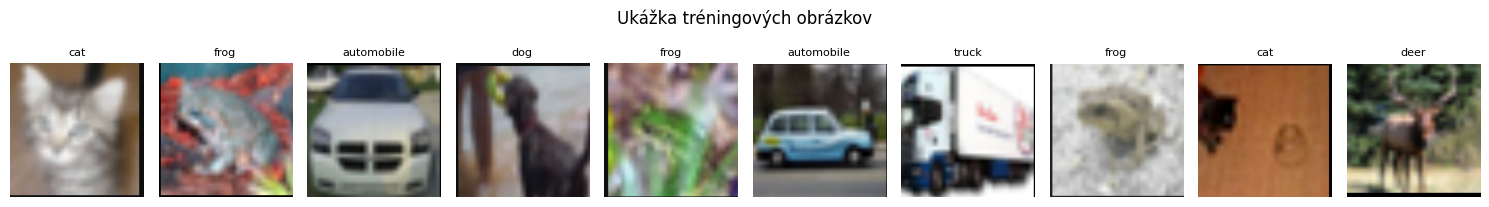

In [7]:
def imshow_batch(loader, n=10):
    imgs, labels = next(iter(loader))
    # De-normalizuj
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = imgs[:n] * std + mean
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    for ax, img, lbl in zip(axes, imgs, labels[:n]):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(CIFAR10_CLASSES[lbl], fontsize=8)
        ax.axis("off")
    plt.suptitle("Ukážka tréningových obrázkov", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/sample_images.png", dpi=120,
                bbox_inches="tight")
    plt.show()

imshow_batch(loaders["train"])


## 4. Definícia modelu


Klasifikačná hlava je nahradená novou `Linear(4096 → 10)` vrstvou s Dropout.


In [8]:
def build_vgg16(num_classes=NUM_CLASSES, dropout=0.5):
    """Predtrénovaný VGG16 s novou klasifikačnou hlavou."""
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    in_features = model.classifier[6].in_features  # 4096
    model.classifier[6] = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model

# Ukáž architektúru
model_preview = build_vgg16()
print(model_preview)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 190MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [9]:
# Prehľad parametrov
total = sum(p.numel() for p in model_preview.parameters())
print(f"Celkový počet parametrov VGG16: {total:,}")
del model_preview


Celkový počet parametrov VGG16: 134,301,514


### Funkcia na nastavenie zmrazených vrstiev

In [10]:
# Index prvej vrstvy každého bloku v model.features
BLOCK_START = {1: 0, 2: 5, 3: 10, 4: 20, 5: 30}

def set_frozen_layers(model, unfreeze_from_block=None):
    """
    unfreeze_from_block:
        None   → len hlava       (E1 – frozen feature extraction)
        5      → block5 + hlava  (E2)
        4      → block4-5 + hlava(E3)
        3      → block3-5 + hlava(E4)
        'all'  → celá sieť       (E5 – full fine-tuning)
    """
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    if unfreeze_from_block == "all":
        for param in model.parameters():
            param.requires_grad = True
    elif unfreeze_from_block is not None:
        start = BLOCK_START[unfreeze_from_block]
        for i, layer in enumerate(model.features):
            if i >= start:
                for param in layer.parameters():
                    param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trénovateľné: {trainable:,} / {total:,}  "
          f"({100*trainable/total:.1f} %)")
    return model


def get_optimizer(model):
    """AdamW s oddelenými LR pre hlavu a backbone."""
    head_ids        = set(id(p) for p in model.classifier.parameters())
    backbone_params = [p for p in model.parameters()
                       if p.requires_grad and id(p) not in head_ids]
    groups = [{"params": list(model.classifier.parameters()), "lr": LR_HEAD}]
    if backbone_params:
        groups.append({"params": backbone_params, "lr": LR_BACKBONE})
    return optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

print("Funkcie set_frozen_layers a get_optimizer definované ✓")


Funkcie set_frozen_layers a get_optimizer definované ✓


## 5. Tréningové funkcie

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total

print("Tréningové funkcie definované ✓")


Tréningové funkcie definované ✓


In [12]:
def run_experiment(name, unfreeze_from_block, loaders,
                   epochs=NUM_EPOCHS, device=DEVICE):
    """Spustí jeden experiment, uloží históriu a best model."""
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {name}")
    print(f"{'='*60}")

    model = build_vgg16().to(device)

    # ── Multi-GPU: DataParallel ak sú dostupné 2× T4 ──────────────────
    if NUM_GPUS > 1:
        model = nn.DataParallel(model)
        print(f"  DataParallel aktívny na {NUM_GPUS} GPU")

    # Nastavenie zmrazených vrstiev (pracujeme s .module pri DataParallel)
    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model = set_frozen_layers(raw_model, unfreeze_from_block)

    optimizer = get_optimizer(raw_model)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    history = {"name": name,
               "train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   [],
               "epoch_time": []}
    best_val_acc, best_weights = 0.0, None
    t_total = time.time()

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = train_epoch(model, loaders["train"], criterion, optimizer, device)
        vl, va = eval_epoch( model, loaders["val"],   criterion, device)
        scheduler.step()
        dt = time.time() - t0

        history["train_loss"].append(round(tl, 4))
        history["train_acc"] .append(round(ta, 2))
        history["val_loss"]  .append(round(vl, 4))
        history["val_acc"]   .append(round(va, 2))
        history["epoch_time"].append(round(dt, 1))

        if va > best_val_acc:
            best_val_acc  = va
            # Ukladaj len váhy základného modelu (bez DataParallel wrappers)
            best_weights  = copy.deepcopy(raw_model.state_dict())

        print(f"  Ep {ep:3d}/{epochs} | "
              f"Train loss:{tl:.4f} acc:{ta:.2f}% | "
              f"Val loss:{vl:.4f} acc:{va:.2f}% | {dt:.1f}s")

    history["total_time_min"] = round((time.time() - t_total) / 60, 2)
    history["best_val_acc"]   = round(best_val_acc, 2)

    # Test s čistým modelom (bez DataParallel)
    raw_model.load_state_dict(best_weights)
    test_model = raw_model.to(device)
    test_loss, test_acc = eval_epoch(test_model, loaders["test"], criterion, device)
    history["test_acc"]  = round(test_acc, 2)
    history["test_loss"] = round(test_loss, 4)

    print(f"\n  ✓ Best Val: {best_val_acc:.2f}% | "
          f"Test: {test_acc:.2f}% | "
          f"Čas: {history['total_time_min']} min")

    # Uloženie
    safe = name.replace(" ", "_").replace("/", "-")
    torch.save(best_weights, f"{RESULTS_DIR}/{safe}_best.pth")
    with open(f"{RESULTS_DIR}/{safe}_history.json", "w") as f:
        json.dump(history, f, indent=2)

    return history, test_model

print("Funkcia run_experiment definovaná ✓")


Funkcia run_experiment definovaná ✓


## 6. Hlavné experimenty (E1 – E5)

### E1 – Frozen feature extraction
*len klasifikačná hlava zmrazená*

In [13]:
hist_e1, model_e1 = run_experiment(
    name="E1 – Frozen feature extraction",
    unfreeze_from_block=None,
    loaders=loaders,
    epochs=NUM_EPOCHS,
)



  EXPERIMENT: E1 – Frozen feature extraction
  DataParallel aktívny na 2 GPU
  Trénovateľné: 119,586,826 / 134,301,514  (89.0 %)
  Ep   1/10 | Train loss:1.3210 acc:64.24% | Val loss:0.6075 acc:82.36% | 189.5s
  Ep   2/10 | Train loss:1.0326 acc:71.68% | Val loss:0.5564 acc:83.86% | 198.3s
  Ep   3/10 | Train loss:0.8899 acc:74.92% | Val loss:0.4953 acc:85.06% | 198.8s
  Ep   4/10 | Train loss:0.7820 acc:77.47% | Val loss:0.4764 acc:85.66% | 199.3s
  Ep   5/10 | Train loss:0.6815 acc:79.90% | Val loss:0.4434 acc:86.40% | 199.1s
  Ep   6/10 | Train loss:0.6080 acc:81.80% | Val loss:0.4253 acc:87.12% | 198.5s
  Ep   7/10 | Train loss:0.5293 acc:83.96% | Val loss:0.4017 acc:87.32% | 199.0s
  Ep   8/10 | Train loss:0.4887 acc:85.14% | Val loss:0.3736 acc:88.36% | 197.9s
  Ep   9/10 | Train loss:0.4539 acc:86.12% | Val loss:0.3754 acc:88.22% | 198.2s
  Ep  10/10 | Train loss:0.4374 acc:86.67% | Val loss:0.3670 acc:88.46% | 198.6s

  ✓ Best Val: 88.46% | Test: 88.03% | Čas: 32.95 min


### E2 – Unfreeze Block 5
*rozmrazený block 5 + hlava*

In [14]:
hist_e2, model_e2 = run_experiment(
    name="E2 – Unfreeze Block 5",
    unfreeze_from_block=5,
    loaders=loaders,
    epochs=NUM_EPOCHS,
)



  EXPERIMENT: E2 – Unfreeze Block 5
  DataParallel aktívny na 2 GPU
  Trénovateľné: 119,586,826 / 134,301,514  (89.0 %)
  Ep   1/10 | Train loss:1.3224 acc:63.74% | Val loss:0.5951 acc:81.44% | 199.1s
  Ep   2/10 | Train loss:1.0451 acc:71.12% | Val loss:0.5325 acc:83.78% | 198.7s
  Ep   3/10 | Train loss:0.8903 acc:74.33% | Val loss:0.4684 acc:85.98% | 199.7s
  Ep   4/10 | Train loss:0.7851 acc:76.98% | Val loss:0.4799 acc:85.70% | 200.0s
  Ep   5/10 | Train loss:0.6947 acc:79.72% | Val loss:0.4412 acc:86.06% | 198.5s
  Ep   6/10 | Train loss:0.6091 acc:81.89% | Val loss:0.3977 acc:87.10% | 199.1s
  Ep   7/10 | Train loss:0.5396 acc:83.78% | Val loss:0.3957 acc:87.30% | 199.4s
  Ep   8/10 | Train loss:0.4947 acc:85.04% | Val loss:0.3938 acc:87.36% | 197.7s
  Ep   9/10 | Train loss:0.4630 acc:85.89% | Val loss:0.3726 acc:88.00% | 198.9s
  Ep  10/10 | Train loss:0.4390 acc:86.53% | Val loss:0.3694 acc:87.94% | 199.5s

  ✓ Best Val: 88.00% | Test: 87.41% | Čas: 33.17 min


### E3 – Unfreeze Block 4–5
*rozmrazené bloky 4–5 + hlava*

In [15]:
hist_e3, model_e3 = run_experiment(
    name="E3 – Unfreeze Block 4–5",
    unfreeze_from_block=4,
    loaders=loaders,
    epochs=NUM_EPOCHS,
)



  EXPERIMENT: E3 – Unfreeze Block 4–5
  DataParallel aktívny na 2 GPU
  Trénovateľné: 129,026,058 / 134,301,514  (96.1 %)
  Ep   1/10 | Train loss:0.8117 acc:74.45% | Val loss:0.5434 acc:82.94% | 225.9s
  Ep   2/10 | Train loss:0.5362 acc:83.57% | Val loss:0.4628 acc:85.72% | 225.3s
  Ep   3/10 | Train loss:0.4136 acc:87.23% | Val loss:0.4369 acc:87.00% | 225.7s
  Ep   4/10 | Train loss:0.3438 acc:89.28% | Val loss:0.3744 acc:89.66% | 225.3s
  Ep   5/10 | Train loss:0.2702 acc:91.72% | Val loss:0.3725 acc:89.64% | 225.4s
  Ep   6/10 | Train loss:0.2078 acc:93.44% | Val loss:0.3534 acc:90.50% | 225.7s
  Ep   7/10 | Train loss:0.1454 acc:95.38% | Val loss:0.3091 acc:91.24% | 225.6s
  Ep   8/10 | Train loss:0.1064 acc:96.62% | Val loss:0.3022 acc:92.30% | 225.8s
  Ep   9/10 | Train loss:0.0811 acc:97.37% | Val loss:0.3075 acc:92.40% | 225.8s
  Ep  10/10 | Train loss:0.0719 acc:97.71% | Val loss:0.3203 acc:92.44% | 225.4s

  ✓ Best Val: 92.44% | Test: 92.13% | Čas: 37.6 min


### E4 – Unfreeze Block 3–5
*rozmrazené bloky 3–5 + hlava*

In [16]:
hist_e4, model_e4 = run_experiment(
    name="E4 – Unfreeze Block 3–5",
    unfreeze_from_block=3,
    loaders=loaders,
    epochs=NUM_EPOCHS,
)



  EXPERIMENT: E4 – Unfreeze Block 3–5
  DataParallel aktívny na 2 GPU
  Trénovateľné: 134,041,354 / 134,301,514  (99.8 %)
  Ep   1/10 | Train loss:1.1870 acc:57.76% | Val loss:0.7727 acc:73.56% | 297.3s
  Ep   2/10 | Train loss:0.7091 acc:76.49% | Val loss:0.5873 acc:79.54% | 300.7s
  Ep   3/10 | Train loss:0.5518 acc:81.79% | Val loss:0.4713 acc:84.38% | 300.6s
  Ep   4/10 | Train loss:0.4406 acc:85.62% | Val loss:0.3868 acc:87.40% | 301.0s
  Ep   5/10 | Train loss:0.3468 acc:88.55% | Val loss:0.3730 acc:87.16% | 300.9s
  Ep   6/10 | Train loss:0.2660 acc:91.17% | Val loss:0.3446 acc:89.16% | 300.3s
  Ep   7/10 | Train loss:0.1988 acc:93.37% | Val loss:0.2947 acc:91.06% | 301.2s
  Ep   8/10 | Train loss:0.1476 acc:95.17% | Val loss:0.2708 acc:92.00% | 301.6s
  Ep   9/10 | Train loss:0.1051 acc:96.51% | Val loss:0.2816 acc:91.76% | 301.4s
  Ep  10/10 | Train loss:0.0897 acc:97.13% | Val loss:0.2733 acc:92.28% | 301.8s

  ✓ Best Val: 92.28% | Test: 91.34% | Čas: 50.11 min


### E5 – Full fine-tuning
*celá sieť trénovateľná*

In [17]:
hist_e5, model_e5 = run_experiment(
    name="E5 – Full fine-tuning",
    unfreeze_from_block='all',
    loaders=loaders,
    epochs=NUM_EPOCHS,
)



  EXPERIMENT: E5 – Full fine-tuning
  DataParallel aktívny na 2 GPU
  Trénovateľné: 134,301,514 / 134,301,514  (100.0 %)
  Ep   1/10 | Train loss:1.0831 acc:62.37% | Val loss:0.6485 acc:78.48% | 421.9s
  Ep   2/10 | Train loss:0.6295 acc:79.56% | Val loss:0.5756 acc:81.64% | 422.0s
  Ep   3/10 | Train loss:0.4897 acc:84.13% | Val loss:0.4348 acc:85.32% | 420.5s
  Ep   4/10 | Train loss:0.3891 acc:87.29% | Val loss:0.3547 acc:88.04% | 420.3s
  Ep   5/10 | Train loss:0.3032 acc:90.26% | Val loss:0.3276 acc:88.82% | 419.7s
  Ep   6/10 | Train loss:0.2184 acc:92.76% | Val loss:0.3017 acc:90.20% | 421.0s
  Ep   7/10 | Train loss:0.1574 acc:94.88% | Val loss:0.2597 acc:91.82% | 421.2s
  Ep   8/10 | Train loss:0.1111 acc:96.35% | Val loss:0.2697 acc:92.22% | 420.5s
  Ep   9/10 | Train loss:0.0793 acc:97.37% | Val loss:0.2380 acc:93.34% | 421.3s
  Ep  10/10 | Train loss:0.0600 acc:97.98% | Val loss:0.2398 acc:93.34% | 421.0s

  ✓ Best Val: 93.34% | Test: 92.76% | Čas: 70.16 min


In [18]:
# Zoznam všetkých histórií hlavných experimentov
all_histories = [hist_e1, hist_e2, hist_e3, hist_e4, hist_e5]
print('Všetky experimenty dokončené ✓')


Všetky experimenty dokončené ✓


## 7. Ablation Study

**A1 – bez dátovej augmentácie**  
Rovnaká stratégia ako E2 (unfreeze block 5), ale trénovanie prebieha bez
RandomHorizontalFlip, RandomCrop a ColorJitter.  
Cieľ: izolovať vplyv augmentácie na generalizáciu.


In [19]:
ABLATION_EPOCHS = 15  # kratší beh pre ablation

hist_a1, _ = run_experiment(
    name="A1 – no augmentation",
    unfreeze_from_block=5,
    loaders=loaders_no_aug,
    epochs=ABLATION_EPOCHS,
)
all_histories.append(hist_a1)
print("Ablation A1 dokončená ✓")



  EXPERIMENT: A1 – no augmentation
  DataParallel aktívny na 2 GPU
  Trénovateľné: 119,586,826 / 134,301,514  (89.0 %)
  Ep   1/15 | Train loss:1.2379 acc:68.20% | Val loss:0.6431 acc:78.78% | 199.9s
  Ep   2/15 | Train loss:1.0292 acc:75.75% | Val loss:0.5209 acc:85.58% | 196.1s
  Ep   3/15 | Train loss:0.8087 acc:79.54% | Val loss:0.4828 acc:86.30% | 195.7s
  Ep   4/15 | Train loss:0.7197 acc:82.38% | Val loss:0.4940 acc:85.06% | 196.4s
  Ep   5/15 | Train loss:0.6195 acc:84.52% | Val loss:0.4595 acc:86.60% | 196.1s
  Ep   6/15 | Train loss:0.5119 acc:86.90% | Val loss:0.4708 acc:87.06% | 196.4s
  Ep   7/15 | Train loss:0.4302 acc:88.89% | Val loss:0.4635 acc:87.54% | 196.8s
  Ep   8/15 | Train loss:0.3723 acc:90.36% | Val loss:0.4483 acc:87.58% | 196.8s
  Ep   9/15 | Train loss:0.3076 acc:91.86% | Val loss:0.4717 acc:88.02% | 197.3s
  Ep  10/15 | Train loss:0.2540 acc:93.19% | Val loss:0.4609 acc:88.18% | 197.0s
  Ep  11/15 | Train loss:0.2111 acc:94.24% | Val loss:0.4915 acc:88.10

## 8. Vizualizácia výsledkov

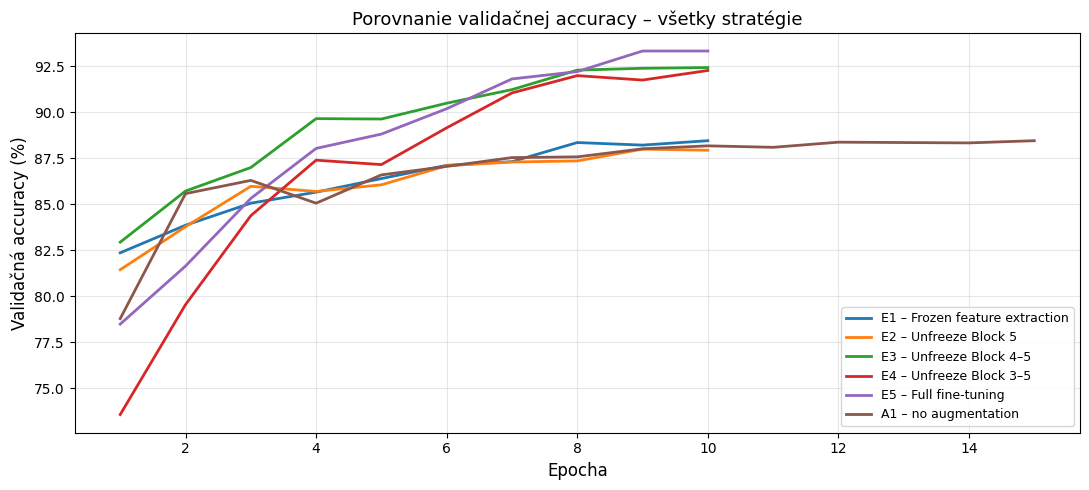

In [20]:
# ─── Validačná accuracy – všetky stratégie ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]

for i, h in enumerate(all_histories):
    ax.plot(range(1, len(h["val_acc"]) + 1), h["val_acc"],
            label=h["name"], color=colors[i % len(colors)], linewidth=2)

ax.set_xlabel("Epocha", fontsize=12)
ax.set_ylabel("Validačná accuracy (%)", fontsize=12)
ax.set_title("Porovnanie validačnej accuracy – všetky stratégie", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_val_all.png", dpi=150)
plt.show()


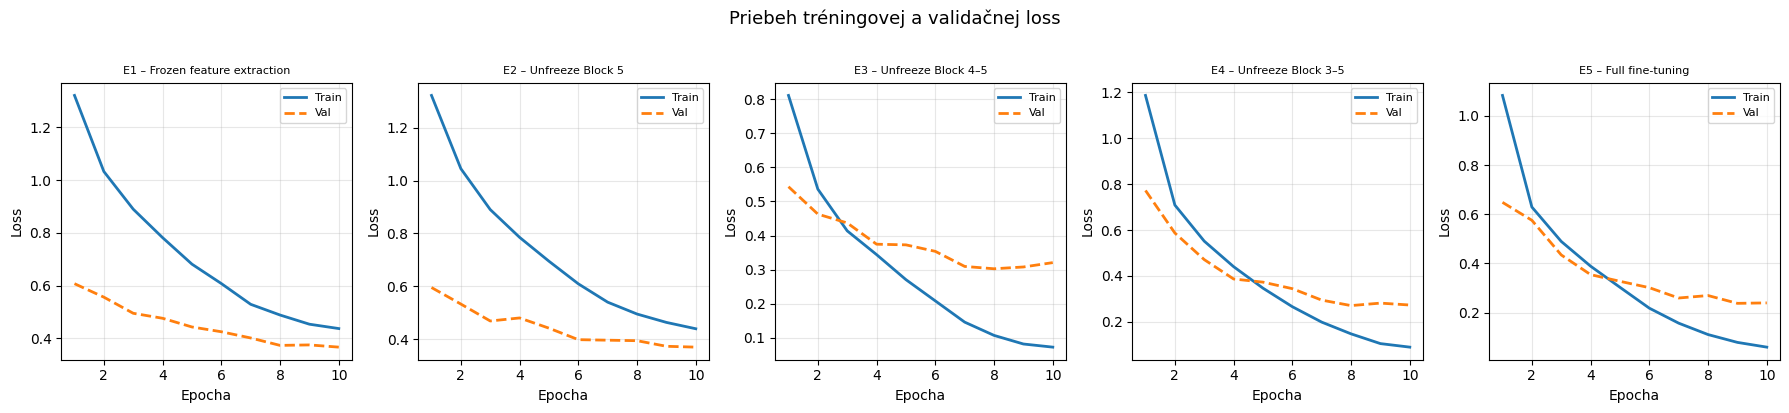

In [21]:
# ─── Train vs Val loss – každý experiment zvlášť ─────────────────────────────
main_exps = [hist_e1, hist_e2, hist_e3, hist_e4, hist_e5]
fig, axes = plt.subplots(1, len(main_exps), figsize=(18, 4), sharey=False)

for ax, h in zip(axes, main_exps):
    eps = range(1, len(h["train_loss"]) + 1)
    ax.plot(eps, h["train_loss"], label="Train", linewidth=2)
    ax.plot(eps, h["val_loss"],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title(h["name"], fontsize=8)
    ax.set_xlabel("Epocha")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Priebeh tréningovej a validačnej loss", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/loss_all.png", dpi=150, bbox_inches="tight")
plt.show()


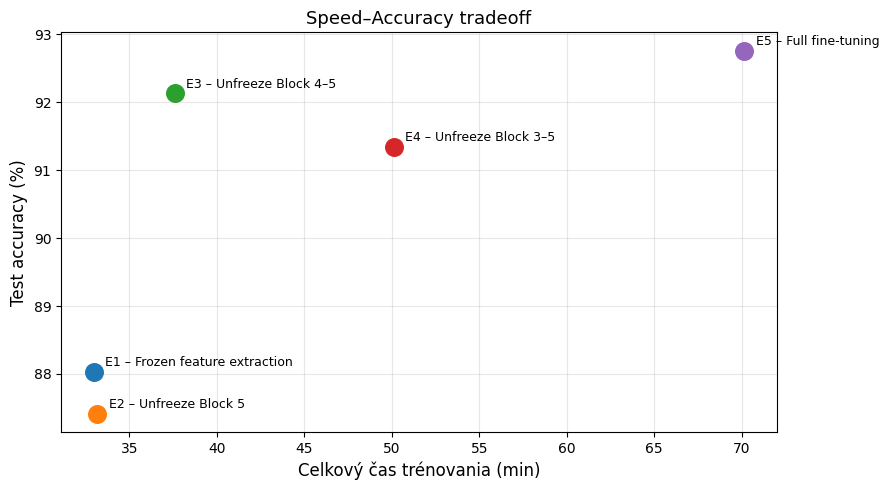

In [22]:
# ─── Speed–Accuracy scatter ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors2 = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]

for i, h in enumerate(main_exps):
    ax.scatter(h["total_time_min"], h["test_acc"],
               color=colors2[i], s=160, zorder=5)
    ax.annotate(h["name"],
                (h["total_time_min"], h["test_acc"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Celkový čas trénovania (min)", fontsize=12)
ax.set_ylabel("Test accuracy (%)", fontsize=12)
ax.set_title("Speed–Accuracy tradeoff", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/speed_accuracy.png", dpi=150)
plt.show()


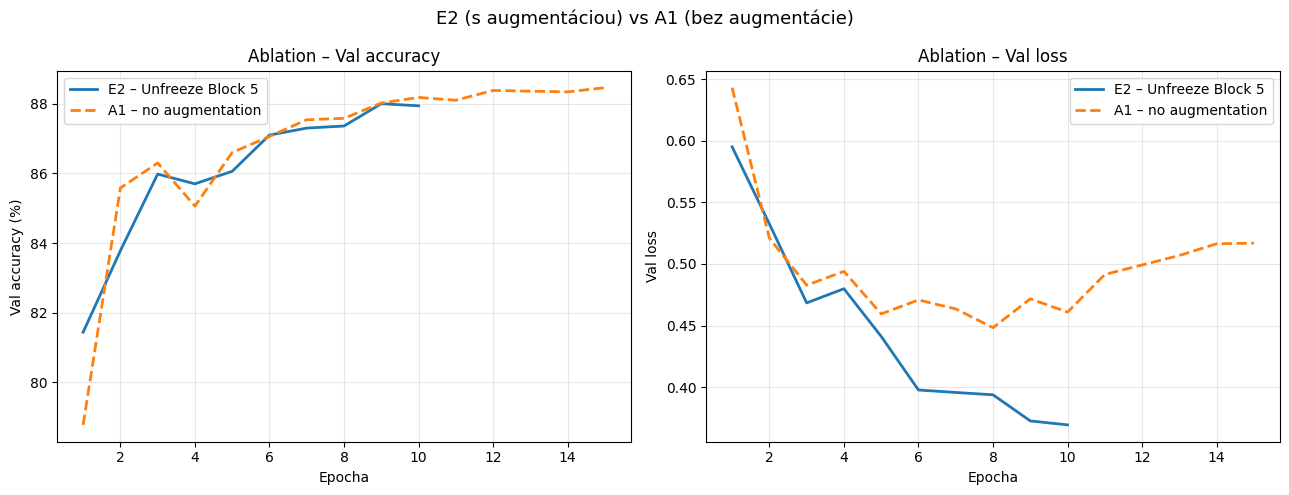

In [23]:
# ─── Ablation: porovnanie E2 vs A1 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Val accuracy
for h, ls in [(hist_e2, "-"), (hist_a1, "--")]:
    axes[0].plot(range(1, len(h["val_acc"]) + 1), h["val_acc"],
                 label=h["name"], linestyle=ls, linewidth=2)
axes[0].set_title("Ablation – Val accuracy")
axes[0].set_xlabel("Epocha"); axes[0].set_ylabel("Val accuracy (%)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Val loss
for h, ls in [(hist_e2, "-"), (hist_a1, "--")]:
    axes[1].plot(range(1, len(h["val_loss"]) + 1), h["val_loss"],
                 label=h["name"], linestyle=ls, linewidth=2)
axes[1].set_title("Ablation – Val loss")
axes[1].set_xlabel("Epocha"); axes[1].set_ylabel("Val loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("E2 (s augmentáciou) vs A1 (bez augmentácie)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/ablation_e2_vs_a1.png", dpi=150)
plt.show()


## 9. Konfúzna matica a analýza chýb

In [24]:
@torch.no_grad()
def compute_confusion_matrix(model, loader, n_cls=NUM_CLASSES, device=DEVICE):
    # Ak model obalený v DataParallel, vybal ho
    raw = model.module if isinstance(model, nn.DataParallel) else model
    raw.eval()
    cm = torch.zeros(n_cls, n_cls, dtype=torch.long)
    for imgs, labels in loader:
        imgs  = imgs.to(device)
        preds = raw(imgs).argmax(1).cpu()
        for t, p in zip(labels, preds):
            cm[t][p] += 1
    return cm


In [25]:
# Vyber najlepší model podľa test accuracy
best_h = max(main_exps, key=lambda h: h.get("test_acc", 0))
print(f"Najlepší experiment: {best_h['name']}  (test acc: {best_h['test_acc']} %)")

# Načítaj váhy
safe_name  = best_h["name"].replace(" ", "_").replace("/", "-")
best_model = build_vgg16().to(DEVICE)
best_model.load_state_dict(
    torch.load(f"{RESULTS_DIR}/{safe_name}_best.pth", map_location=DEVICE)
)

# Vypočítaj konfúznu maticu
cm = compute_confusion_matrix(best_model, loaders["test"])
np.save(f"{RESULTS_DIR}/confusion_matrix_best.npy", cm)
print("Konfúzna matica vypočítaná ✓")


Najlepší experiment: E5 – Full fine-tuning  (test acc: 92.76 %)
Konfúzna matica vypočítaná ✓


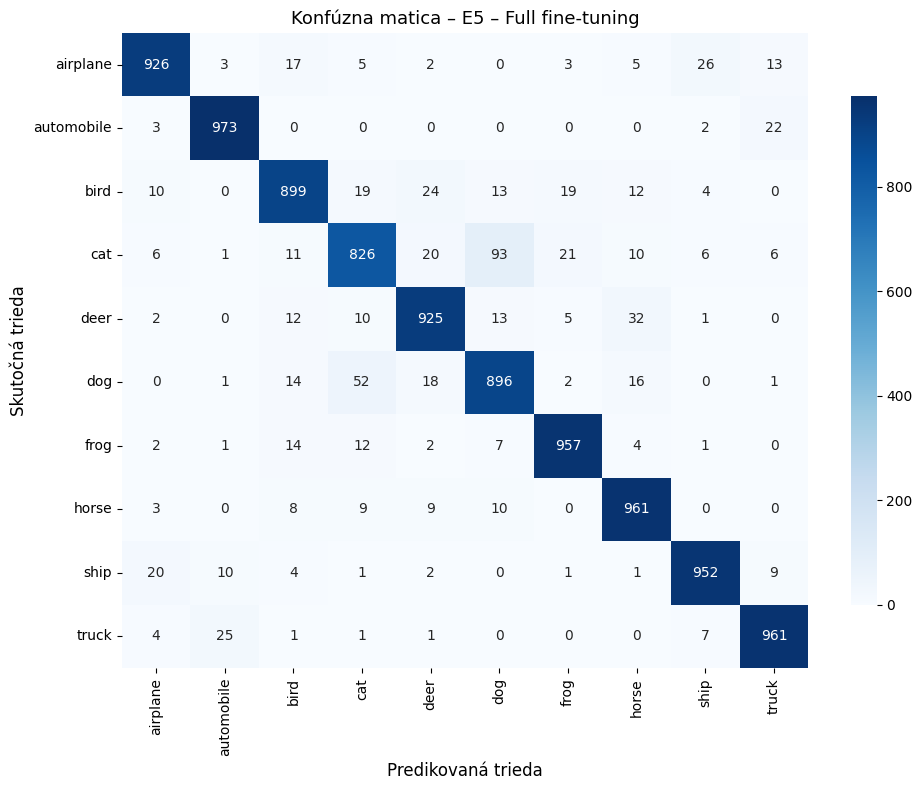

In [26]:
# Vykresli konfúznu maticu
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_xlabel("Predikovaná trieda", fontsize=12)
ax.set_ylabel("Skutočná trieda", fontsize=12)
ax.set_title(f"Konfúzna matica – {best_h['name']}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150)
plt.show()


In [27]:
# Top zamenané dvojice tried
confusions = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            confusions.append((cm[i][j], CIFAR10_CLASSES[i], CIFAR10_CLASSES[j]))
confusions.sort(reverse=True)

print("Top 10 najčastejšie zamenané dvojice tried:")
print(f"{'Skutočná':15s} {'Predikovaná':15s} {'Počet chýb':>12s}")
print("-" * 45)
for count, true_cls, pred_cls in confusions[:10]:
    print(f"{true_cls:15s} {pred_cls:15s} {count:>12d}")


Top 10 najčastejšie zamenané dvojice tried:
Skutočná        Predikovaná       Počet chýb
---------------------------------------------
cat             dog                       93
dog             cat                       52
deer            horse                     32
airplane        ship                      26
truck           automobile                25
bird            deer                      24
automobile      truck                     22
cat             frog                      21
ship            airplane                  20
cat             deer                      20


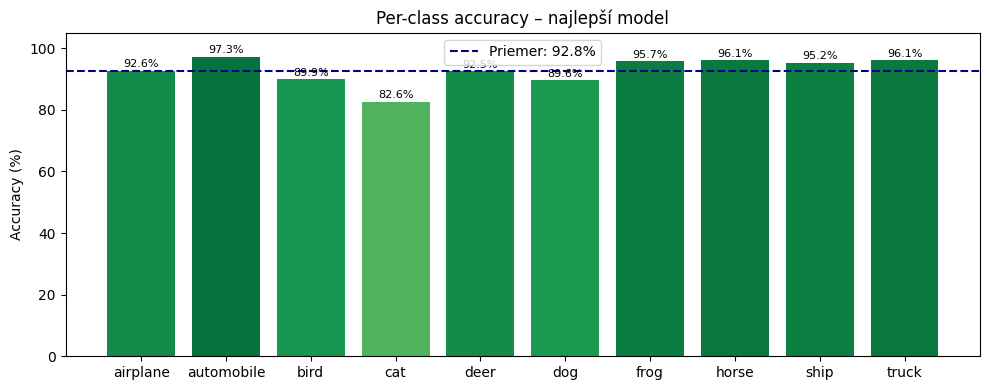

In [28]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CIFAR10_CLASSES, per_class_acc,
              color=plt.cm.RdYlGn(per_class_acc / 100))
ax.axhline(per_class_acc.mean(), color="navy", linestyle="--",
           label=f"Priemer: {per_class_acc.mean():.1f}%")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-class accuracy – najlepší model")
ax.set_ylim(0, 105)
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_class_accuracy.png", dpi=150)
plt.show()


## 10. Súhrnná tabuľka výsledkov

In [29]:
rows = []
for h in all_histories:
    avg_ep = (sum(h.get("epoch_time", [0])) /
              max(len(h.get("epoch_time", [1])), 1))
    rows.append({
        "Stratégia":            h["name"],
        "Best Val Acc (%)":     h.get("best_val_acc", h["val_acc"][-1]),
        "Test Acc (%)":         h.get("test_acc", "–"),
        "Test Loss":            h.get("test_loss", "–"),
        "Čas celkom (min)":     h.get("total_time_min", "–"),
        "Čas/epocha (s)":       round(avg_ep, 1),
        "Epoch":                len(h["val_acc"]),
    })

df_results = pd.DataFrame(rows)
df_results.to_csv(f"{RESULTS_DIR}/summary_results.csv", index=False)

display(df_results.style
        .highlight_max(subset=["Best Val Acc (%)", "Test Acc (%)"],
                       color="lightgreen")
        .highlight_min(subset=["Čas celkom (min)"], color="lightyellow")
        .format(precision=2))

print(f"\nSúhrn uložený do: {RESULTS_DIR}/summary_results.csv")


,Stratégia,Best Val Acc (%),Test Acc (%),Test Loss,Čas celkom (min),Čas/epocha (s),Epoch
0,E1 – Frozen feature extraction,88.46,88.03,0.40,32.95,197.70,10
1,E2 – Unfreeze Block 5,88.00,87.41,0.41,33.17,199.10,10
2,E3 – Unfreeze Block 4–5,92.44,92.13,0.34,37.60,225.60,10
3,E4 – Unfreeze Block 3–5,92.28,91.34,0.31,50.11,300.70,10
4,E5 – Full fine-tuning,93.34,92.76,0.27,70.16,420.90,10
5,A1 – no augmentation,88.46,88.62,0.61,49.19,196.70,15



Súhrn uložený do: /kaggle/working/results/summary_results.csv


In [30]:
# Počet trénovateľných parametrov pre každú stratégiu
print("Počty trénovateľných parametrov:\n")
configs = [
    ("E1 – Frozen", None),
    ("E2 – Block 5", 5),
    ("E3 – Block 4-5", 4),
    ("E4 – Block 3-5", 3),
    ("E5 – Full", "all"),
]
for label, ufb in configs:
    m = build_vgg16()
    set_frozen_layers(m, ufb)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f"  {label:22s}: {trainable:>10,} / {total:>10,}  ({100*trainable/total:.1f}%)")
    del m


Počty trénovateľných parametrov:

  Trénovateľné: 119,586,826 / 134,301,514  (89.0 %)
  E1 – Frozen           : 119,586,826 / 134,301,514  (89.0%)
  Trénovateľné: 119,586,826 / 134,301,514  (89.0 %)
  E2 – Block 5          : 119,586,826 / 134,301,514  (89.0%)
  Trénovateľné: 129,026,058 / 134,301,514  (96.1 %)
  E3 – Block 4-5        : 129,026,058 / 134,301,514  (96.1%)
  Trénovateľné: 134,041,354 / 134,301,514  (99.8 %)
  E4 – Block 3-5        : 134,041,354 / 134,301,514  (99.8%)
  Trénovateľné: 134,301,514 / 134,301,514  (100.0 %)
  E5 – Full             : 134,301,514 / 134,301,514  (100.0%)
